# Pre-processing

In [ ]:
''' Requirements

scikit-learn==1.6.1
xgboost==3.2.0
numpy==2.0.2
pandas==2.2.2
matplotlib==3.10.0
joblib==1.5.3
shap==0.50.0
openpyxl==3.1.5
streamlit==1.54.0

'''

In [1]:
# Stratified Splitting to 80% Training and 20% testing

import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_excel('Master Sheet_Combined_BEFORE IMPUTATION.xlsx')

# Define the target variable
target_column = 'mort in'

# Split the data: 80% for training and 20% for testing
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df[target_column])

# Save the splits to Excel files
train_df.to_excel('B_Train80_NoLKG.xlsx', index=False)
test_df.to_excel('B_Test20_NoLKG.xlsx', index=False)

print("Files Saved!")


Files Saved!


In [2]:
# Imputing Missing Mastersheet Using Random Forest Regressor
# Avoided Data Leakage from Test dataset & Target variable

# And saved the imputer

import joblib
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

# Load training and test datasets
train_path = "B_Train80_NoLKG.xlsx"
test_path = "B_Test20_NoLKG.xlsx"
train_df = pd.read_excel(train_path)
test_df = pd.read_excel(test_path)

# Define target column (to exclude from imputation)
target_col = "mort in"

# Identify numeric columns with missing values (excluding target)
num_cols = train_df.select_dtypes(include=['float64', 'int64']).columns
impute_cols = [col for col in num_cols if col != target_col and (train_df[col].isnull().sum() > 0 or test_df[col].isnull().sum() > 0)]

# Display missing value counts before imputation
print("Missing values before imputation (Training):")
print(train_df[impute_cols].isnull().sum())
print("\nMissing values before imputation (Testing):")
print(test_df[impute_cols].isnull().sum())

# Initialize Random Forest Regressor-based imputer
imputer = IterativeImputer(estimator=RandomForestRegressor(n_estimators=100, random_state=42),
                           max_iter=10, random_state=42)

# Fit imputer on training data only
imputer.fit(train_df[impute_cols])

# Transform both training and test sets
train_df[impute_cols] = imputer.transform(train_df[impute_cols])
test_df[impute_cols] = imputer.transform(test_df[impute_cols])

# Define rounding rules
rounding_dict = {
    "ones": ["spo2", "plt", "alt", "ast"],
    "tenths": ["weight", "hb", "mcv", "ptt", "urea"],
    "hundredths": ["inr", "creat"]
}

# Apply rounding
for col in rounding_dict["ones"]:
    for df in [train_df, test_df]:
        if col in df.columns:
            df[col] = df[col].round(0).astype(int)

for col in rounding_dict["tenths"]:
    for df in [train_df, test_df]:
        if col in df.columns:
            df[col] = df[col].round(1)

for col in rounding_dict["hundredths"]:
    for df in [train_df, test_df]:
        if col in df.columns:
            df[col] = df[col].round(2)

# Display missing value counts after imputation
print("\nMissing values after imputation (Training):")
print(train_df[impute_cols].isnull().sum())
print("\nMissing values after imputation (Testing):")
print(test_df[impute_cols].isnull().sum())

# Save the imputed datasets
train_df.to_excel("B_Train80_NoLKG_Imputed.xlsx", index=False)
test_df.to_excel("B_Test20_NoLKG_Imputed.xlsx", index=False)
print("\nImputed datasets saved.")
joblib.dump(imputer, "rf_iterative_imputer.pkl")
print("Imputer saved.")

Missing values before imputation (Training):
weight     3
spo2      78
mcv        2
inr       12
ptt       55
creat      9
urea      15
alt       38
ast       50
dtype: int64

Missing values before imputation (Testing):
weight     0
spo2      26
mcv        0
inr        5
ptt       19
creat      1
urea       2
alt       16
ast       19
dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(



Missing values after imputation (Training):
weight    0
spo2      0
mcv       0
inr       0
ptt       0
creat     0
urea      0
alt       0
ast       0
dtype: int64

Missing values after imputation (Testing):
weight    0
spo2      0
mcv       0
inr       0
ptt       0
creat     0
urea      0
alt       0
ast       0
dtype: int64

Imputed datasets saved.
Imputer saved.


In [3]:
# Applying Normalization to the Training dataset

import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import joblib

# Load the training dataset
df_train = pd.read_excel('B_Train80_NoLKG_Imputed.xlsx')

# Identify numerical and categorical columns
numerical_cols = df_train.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df_train.select_dtypes(include=['object', 'category']).columns

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Apply normalization to the numerical columns
df_train[numerical_cols] = scaler.fit_transform(df_train[numerical_cols])

# Combine the normalized numerical data with the categorical data
df_train_normalized = pd.concat([df_train[numerical_cols], df_train[categorical_cols]], axis=1)

# Save the normalized dataset to a new Excel file
df_train_normalized.to_excel('B_Train80_NoLKG_Imputed_NORM.xlsx', index=False)
print("Normalized training dataset saved!")

# Save the scaler to a file for later use on the test dataset
scaler_file_path = 'NoLKG_SCALER.joblib'
joblib.dump(scaler, scaler_file_path)
print("Scaler saved!")


Normalized training dataset saved!
Scaler saved!


In [4]:
# Applying Normalization to the Test dataset

import pandas as pd
import joblib

# Load the test dataset
df_test = pd.read_excel('B_Test20_NoLKG_Imputed.xlsx')

# Identify numerical and categorical columns
numerical_cols = df_test.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df_test.select_dtypes(include=['object', 'category']).columns

# Load the saved scaler (trained on training data)
scaler = joblib.load('NoLKG_SCALER.joblib')

# Apply normalization to numerical columns only
df_test[numerical_cols] = scaler.transform(df_test[numerical_cols])

# Save the normalized test dataset
df_test.to_excel('B_Test20_NoLKG_Imputed_NORMxx.xlsx', index=False)
print("Normalized test dataset saved!")


Normalized test dataset saved!


# Feature Selection

B_Train80_NoLKG_Imputed_NORM_SHAP.xlsx


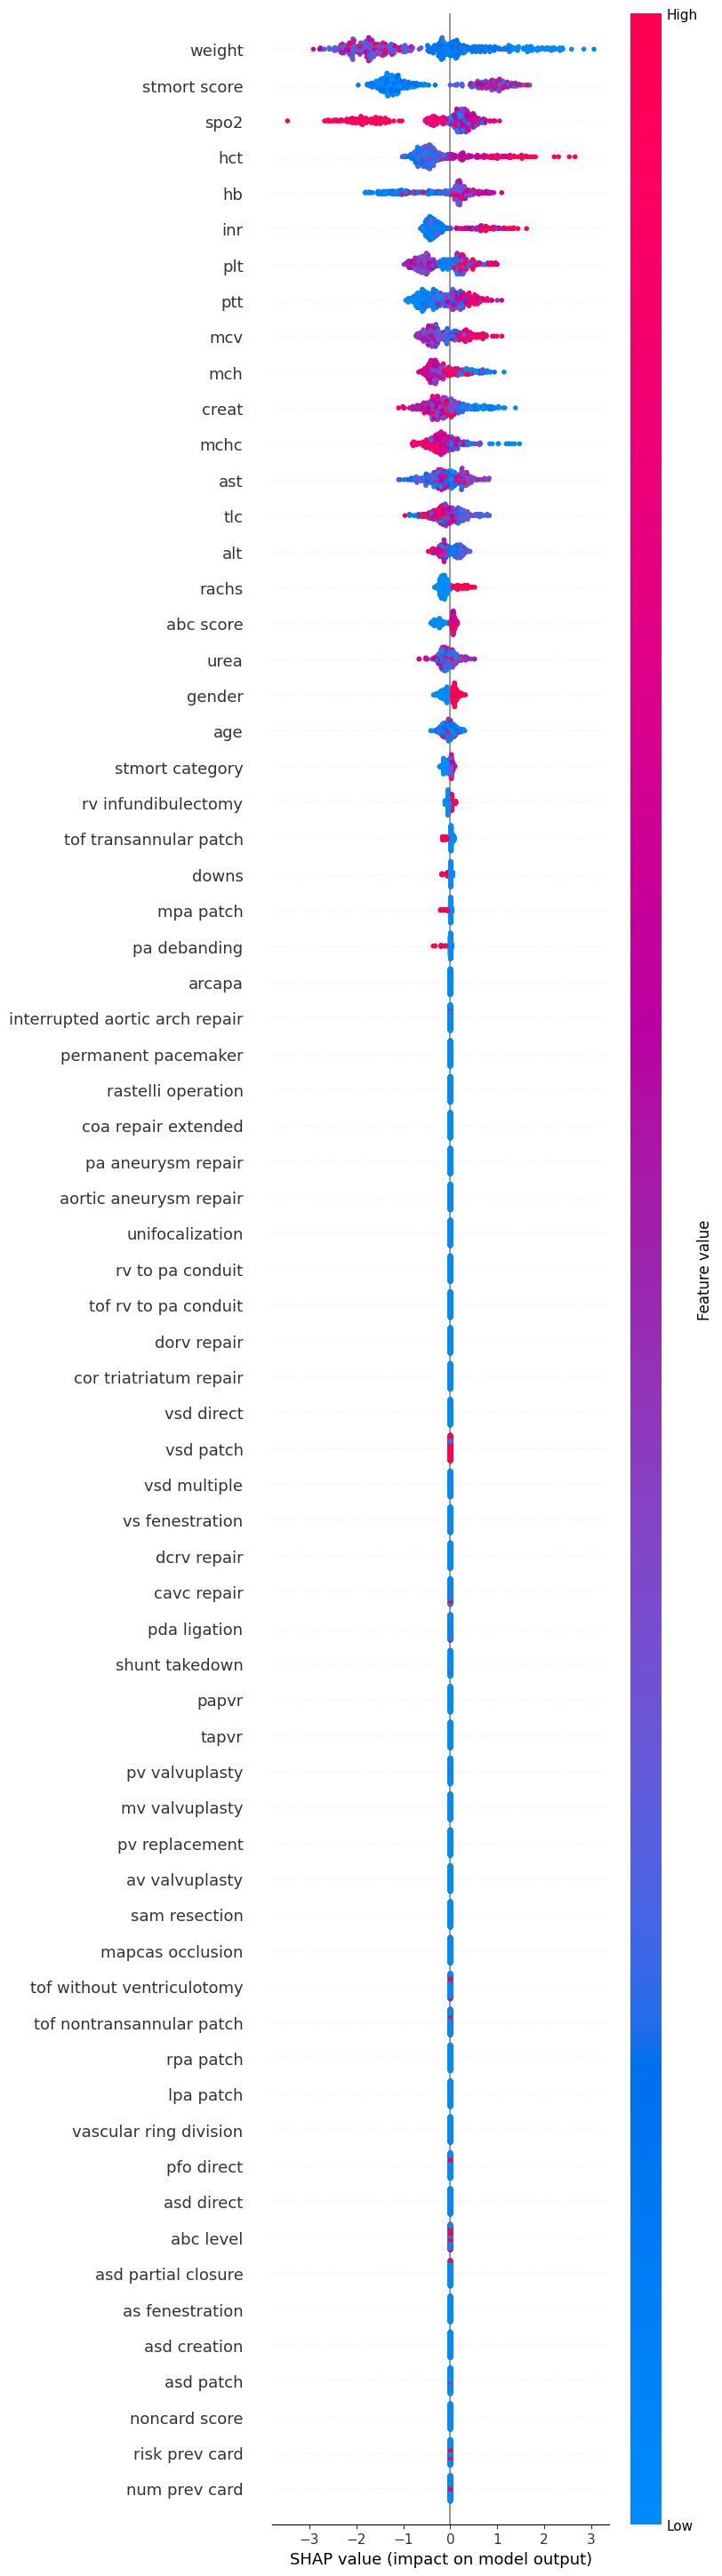

In [5]:
# SHAP Summary Plot for Global Importance

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# Load the training dataset
train_file_path = "B_Train80_NoLKG_Imputed_NORM.xlsx"
train_sheet_name = "Sheet1"
train_df = pd.read_excel(train_file_path, sheet_name=train_sheet_name)

# Separate features and target variable in the training dataset
X_train = train_df.drop("mort in", axis=1)
y_train = train_df["mort in"]

# Train XGBoost model on the training dataset
final_model = XGBClassifier()
final_model.fit(X_train, y_train)

# Initialize SHAP explainer
explainer = shap.TreeExplainer(final_model)

# Compute SHAP values for the training dataset
shap_values = explainer.shap_values(X_train)

# Compute the mean absolute SHAP value for each feature
shap_importance = np.abs(shap_values).mean(axis=0)

# Create a DataFrame for SHAP importance
shap_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'SHAP_Importance': shap_importance
})

# Sort features by SHAP importance in descending order
shap_importance_df = shap_importance_df.sort_values(by="SHAP_Importance", ascending=False)

# Save all SHAP feature importance results to an Excel file
shap_importance_df.to_excel("B_Train80_NoLKG_Imputed_NORM_SHAP.xlsx", index=False)

# Print confirmation
print("B_Train80_NoLKG_Imputed_NORM_SHAP.xlsx")

# SHAP Summary Plot for feature importance visualization
shap.summary_plot(shap_values, X_train, max_display=len(X_train.columns), show=True)


In [6]:
# SHAP Dependence Plot to Check for Redundant Features

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from scipy.stats import spearmanr

# Load the training dataset
train_file_path = "B_Train80_NoLKG_Imputed_NORM_RmvZero.xlsx"
train_sheet_name = "Sheet1"
train_df = pd.read_excel(train_file_path, sheet_name=train_sheet_name)

# Separate features and target variable in the training dataset
X_train = train_df.drop("mort in", axis=1)
y_train = train_df["mort in"]

# Train XGBoost model on the training dataset
final_model = XGBClassifier()
final_model.fit(X_train, y_train)

# Initialize SHAP explainer
explainer = shap.TreeExplainer(final_model)

# Compute SHAP values for the training dataset only
shap_values = explainer.shap_values(X_train)
X_combined = X_train  # Since we're using only the training data

# Compute SHAP importance for each feature
shap_importance = np.abs(shap_values).mean(axis=0)

# Identify Redundant Features
shap_df = pd.DataFrame(shap_values, columns=X_combined.columns)  # Convert SHAP values to DataFrame
correlation_matrix = shap_df.corr(method="spearman").abs()  # Compute Spearman correlation for SHAP values
redundant_features = []  # List to store redundant feature pairs

correlation_threshold = 0.8  # Correlation threshold
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        if correlation_matrix.iloc[i, j] > correlation_threshold:
            redundant_features.append((correlation_matrix.columns[i], correlation_matrix.columns[j]))

# Convert results into a DataFrame
df_redundant = pd.DataFrame(redundant_features, columns=["Feature_1", "Feature_2"])

print(f"Redundant Feature Pairs: {len(df_redundant)}")
print(df_redundant)


Redundant Feature Pairs: 0
Empty DataFrame
Columns: [Feature_1, Feature_2]
Index: []


# Hyperparameters Search

In [8]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 11.6 MB/s eta 0:00:00


In [9]:
# Optuna XGBoost x1000, best hyperparameters

import optuna
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Load the training dataset
train_df = pd.read_excel('B_Train80_NoLKG_Imputed_NORM_RmvZero.xlsx')
X_train = train_df.drop('mort in', axis=1)
y_train = train_df['mort in']

# Define the Optuna objective function using cross-validation
def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.1),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_uniform('subsample', 0.8, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0),
        'colsample_bylevel': trial.suggest_uniform('colsample_bylevel', 0.6, 1.0),
        'gamma': trial.suggest_uniform('gamma', 0, 3),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'scale_pos_weight': trial.suggest_int('scale_pos_weight', 5, 15),
        'reg_alpha': trial.suggest_uniform('reg_alpha', 0, 0.5),
        'reg_lambda': trial.suggest_uniform('reg_lambda', 0.5, 1.0),
        'random_state': 42
    }

    # Initialize the XGBoost model
    model = xgb.XGBClassifier(**params)

    # Cross-validation strategy
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Cross-validation AUC
    auc_scores = cross_val_score(model, X_train, y_train, scoring='roc_auc', cv=cv, n_jobs=-1)
    mean_auc = np.mean(auc_scores)

    return mean_auc

# Set up the Optuna study
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Start Optuna optimization
print("Starting Optuna Hyperparameter Optimization...")
study.optimize(objective, n_trials=1000)

# Get the single best trial
best_trial = study.best_trial

# Output the best hyperparameters
print("\nBest Hyperparameters based on Cross-Validation AUC:")
print(f"\nTrial {best_trial.number}: {best_trial.params}, CV AUC: {best_trial.value:.4f}")


[I 2026-02-22 20:18:48,885] A new study created in memory with name: no-name-08962955-8033-4745-9ec6-6c2ecaa9923d


Starting Optuna Hyperparameter Optimization...


/tmp/ipython-input-704788517.py:21: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.1),
/tmp/ipython-input-704788517.py:23: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.8, 1.0),
/tmp/ipython-input-704788517.py:24: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0),
/tmp/ipython-input-704788517.py:25: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This f

KeyboardInterrupt: 

In [10]:
# Optuna Bagging x1000, best hyperparameters

import optuna
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
import joblib

# Load the training dataset
train_df = pd.read_excel('B_Train80_NoLKG_Imputed_NORM_RmvZero.xlsx')
X_train = train_df.drop('mort in', axis=1)
y_train = train_df['mort in']

# Define the XGBoost Model with fixed hyperparameters
def create_xgb_model():
    return xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=42,
        max_depth=3,
        learning_rate=0.01928044904842136,
        min_child_weight=1,
        subsample=0.8614501903065227,
        colsample_bytree=0.8796696936441701,
        colsample_bylevel=0.7324794662581371,
        gamma=1.193696245915529,
        n_estimators=100,
        scale_pos_weight=5,
        reg_alpha=0.00032536986825252743,
        reg_lambda=0.5447906698870625
    )

# Define the objective function
def objective(trial):
    bagging_params = {
        'n_estimators': trial.suggest_int('n_estimators', 8, 12),
        'max_samples': trial.suggest_uniform('max_samples', 0.9, 0.95),
        'max_features': trial.suggest_uniform('max_features', 0.85, 0.92),
        'bootstrap': True,
        'random_state': 42
    }

    xgb_model = create_xgb_model()

    bagging_model = BaggingClassifier(
        estimator=xgb_model,
        n_estimators=bagging_params['n_estimators'],
        max_samples=bagging_params['max_samples'],
        max_features=bagging_params['max_features'],
        bootstrap=bagging_params['bootstrap'],
        random_state=bagging_params['random_state']
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = cross_val_score(bagging_model, X_train, y_train, scoring='roc_auc', cv=cv, n_jobs=-1)
    return np.mean(auc_scores)

# Set up and run Optuna study
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
print("Starting Optuna Hyperparameter Optimization...")
study.optimize(objective, n_trials=1000)

# Output the single best hyperparameter set
best_trial = study.best_trial
print("\nBest Hyperparameters based on Mean Cross-Validation AUC:")
print(f"Trial {best_trial.number}: {best_trial.params}, Mean CV AUC: {best_trial.value:.4f}")

# Train final model with best parameters
best_params = best_trial.params
best_xgb_model = create_xgb_model()

best_bagging_model = BaggingClassifier(
    estimator=best_xgb_model,
    n_estimators=best_params['n_estimators'],
    max_samples=best_params['max_samples'],
    max_features=best_params['max_features'],
    bootstrap=True,
    random_state=42
)

best_bagging_model.fit(X_train, y_train)

# Evaluate final model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_auc_scores = cross_val_score(best_bagging_model, X_train, y_train, scoring='roc_auc', cv=cv, n_jobs=-1)
mean_final_auc = np.mean(final_auc_scores)

# F1 Scores
y_pred_proba = cross_val_predict(best_bagging_model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)
f1_class0 = f1_score(y_train, y_pred, pos_label=0)
f1_class1 = f1_score(y_train, y_pred, pos_label=1)

print(f"\n🔹 Final Mean Cross-Validation AUC: {mean_final_auc:.4f}")
print(f"🔹 Final F1 Score (Class 0): {f1_class0:.4f}")
print(f"🔹 Final F1 Score (Class 1): {f1_class1:.4f}")

print("Best Bagging XGBoost model ready.")


[I 2026-02-22 20:19:50,377] A new study created in memory with name: no-name-23cdf4b9-8d5e-4113-8f58-3b977a1254b9


Starting Optuna Hyperparameter Optimization...


/tmp/ipython-input-3606688727.py:40: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'max_samples': trial.suggest_uniform('max_samples', 0.9, 0.95),
/tmp/ipython-input-3606688727.py:41: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'max_features': trial.suggest_uniform('max_features', 0.85, 0.92),
[I 2026-02-22 20:19:59,136] Trial 0 finished with value: 0.8307318244170097 and parameters: {'n_estimators': 9, 'max_samples': 0.9475357153204957, 'max_features': 0.9012395759267984}. Best is trial 0 with value: 0.8307318244170097.
/tmp/ipython-input-3606688727.py:40: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/

KeyboardInterrupt: 

# Training & Testing

In [1]:
import xgboost, numpy, pandas, matplotlib, joblib, shap, streamlit, sklearn
import sys

print("Python:", sys.executable)
print("xgboost:", xgboost.__version__, "from", xgboost.__file__)
print("numpy:", numpy.__version__, "from", numpy.__file__)
print("pandas:", pandas.__version__, "from", pandas.__file__)
print("matplotlib:", matplotlib.__version__, "from", matplotlib.__file__)
print("joblib:", joblib.__version__, "from", joblib.__file__)
print("shap:", shap.__version__, "from", shap.__file__)
print("streamlit:", streamlit.__version__, "from", streamlit.__file__)
print("sklearn:", sklearn.__version__, "from", sklearn.__file__)

C:\Users\islmo\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: c:\Users\islmo\AppData\Local\Programs\Python\Python312\python.exe
xgboost: 3.2.0 from C:\Users\islmo\AppData\Roaming\Python\Python312\site-packages\xgboost\__init__.py
numpy: 2.0.2 from C:\Users\islmo\AppData\Roaming\Python\Python312\site-packages\numpy\__init__.py
pandas: 2.2.2 from C:\Users\islmo\AppData\Roaming\Python\Python312\site-packages\pandas\__init__.py
matplotlib: 3.10.0 from C:\Users\islmo\AppData\Roaming\Python\Python312\site-packages\matplotlib\__init__.py
joblib: 1.5.3 from C:\Users\islmo\AppData\Roaming\Python\Python312\site-packages\joblib\__init__.py
shap: 0.50.0 from C:\Users\islmo\AppData\Roaming\Python\Python312\site-packages\shap\__init__.py
streamlit: 1.54.0 from C:\Users\islmo\AppData\Roaming\Python\Python312\site-packages\streamlit\__init__.py
sklearn: 1.6.1 from C:\Users\islmo\AppData\Roaming\Python\Python312\site-packages\sklearn\__init__.py


Performing cross-validated prediction for threshold selection...
Threshold by Youden's Index: 0.0776
Youden's Index at threshold: 0.5053
Final AUC: 0.7990
F1 Score (Class 0): 0.7688
F1 Score (Class 1): 0.3529
Overall F1 Score: 0.3529


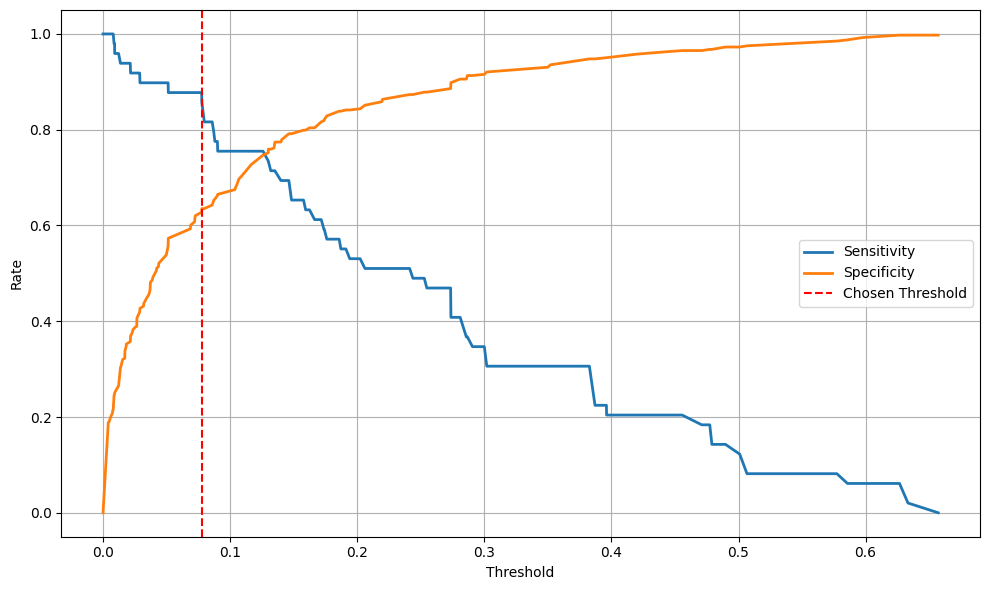

Training final calibrated model on full data (with internal CV)...
Calibrated model training complete!


In [2]:
# CALIBRATING BEFORE THREHSOLD Youden

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import roc_auc_score, f1_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.calibration import CalibratedClassifierCV
import joblib
import matplotlib.pyplot as plt

# Load Training Dataset
train_df = pd.read_excel('B_Train80_NoLKG_Imputed_NORM_RmvZero.xlsx')
X_train = train_df.drop('mort in', axis=1)
y_train = train_df['mort in']

# Define the XGBoost Base Model
def create_xgb_model():
    return xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=42,
        max_depth=3,
        learning_rate=0.01928044904842136,
        min_child_weight=1,
        subsample=0.8614501903065227,
        colsample_bytree=0.8796696936441701,
        colsample_bylevel=0.7324794662581371,
        gamma=1.193696245915529,
        n_estimators=100,
        scale_pos_weight=5,
        reg_alpha=0.00032536986825252743,
        reg_lambda=0.5447906698870625
    )

# Create BaggingClassifier
bagging_model = BaggingClassifier(
    estimator=create_xgb_model(),
    n_estimators=12,
    max_samples=0.9106169555339139,
    max_features=0.862727747704497,
    bootstrap=True,
    random_state=42
)

# Apply Calibration Using Internal CV
calibrated_model = CalibratedClassifierCV(bagging_model, method='isotonic', cv=5)

# Cross-Validated Probabilities for Threshold Tuning
print("Performing cross-validated prediction for threshold selection...")
y_pred_proba_cv = cross_val_predict(calibrated_model, X_train, y_train, cv=5, method='predict_proba')[:, 1]

# ROC & Youden's Index Threshold Optimization
fpr, tpr, thresholds = roc_curve(y_train, y_pred_proba_cv)
specificity = 1 - fpr
youden_index = tpr + specificity - 1
youden_threshold = thresholds[np.argmax(youden_index)]
best_youden = youden_index[np.argmax(youden_index)]

print(f"Threshold by Youden's Index: {youden_threshold:.4f}")
print(f"Youden's Index at threshold: {best_youden:.4f}")

# Evaluate Performance with Youden Threshold
y_pred_youden = (y_pred_proba_cv > youden_threshold).astype(int)
f1_class_0 = f1_score(y_train, y_pred_youden, pos_label=0)
f1_class_1 = f1_score(y_train, y_pred_youden, pos_label=1)
overall_f1 = f1_class_1
auc_score = roc_auc_score(y_train, y_pred_proba_cv)

print(f"Final AUC: {auc_score:.4f}")
print(f"F1 Score (Class 0): {f1_class_0:.4f}")
print(f"F1 Score (Class 1): {f1_class_1:.4f}")
print(f"Overall F1 Score: {overall_f1:.4f}")

# Plot Sensitivity & Specificity
plt.figure(figsize=(10, 6))
plt.plot(thresholds, tpr, label="Sensitivity", linewidth=2)
plt.plot(thresholds, specificity, label="Specificity", linewidth=2)
plt.axvline(youden_threshold, color='red', linestyle='--', label='Chosen Threshold')
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('Sensitivity_Specificity_vs_Threshold.png', dpi=600)
plt.show()

# Final Training on All Data (with Calibration)
print("Training final calibrated model on full data (with internal CV)...")
calibrated_model.fit(X_train, y_train)
print("Calibrated model training complete!")

# Save the Calibrated Model
# joblib.dump(calibrated_model, 'F_Calibrated_XGBoost_Bagging_Model.pkl')
# print("Final calibrated model saved as 'F_Calibrated_XGBoost_Bagging_Model.pkl'")


Performing cross-validated prediction for threshold selection...
Threshold by Youden's Index: 0.1040
Youden's Index at threshold: 0.5464
Final AUC: 0.8165
F1 Score (Class 0): 0.8195
F1 Score (Class 1): 0.3883
Overall F1 Score: 0.3883


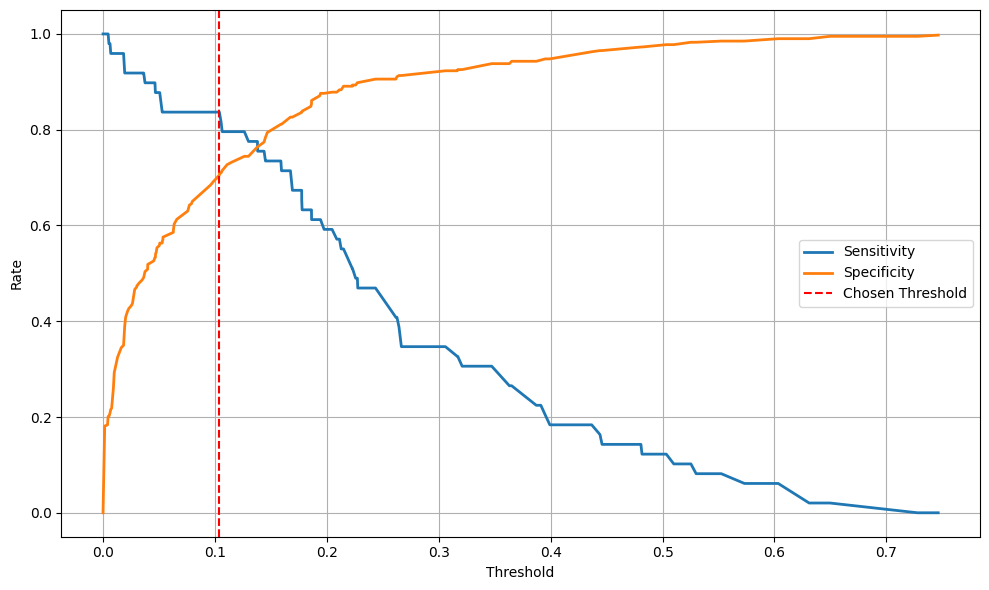

Training final calibrated model on full data (with internal CV)...
Calibrated model training complete!


In [5]:
# CALIBRATING BEFORE THREHSOLD Youden

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import roc_auc_score, f1_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.calibration import CalibratedClassifierCV
import joblib
import matplotlib.pyplot as plt

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# Load Training Dataset
train_df = pd.read_excel('B_Train80_NoLKG_Imputed_NORM_RmvZero.xlsx')
X_train = train_df.drop('mort in', axis=1)
y_train = train_df['mort in']

# Define the XGBoost Base Model
def create_xgb_model():
    return xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=42,
        max_depth=3,
        n_jobs=1,          # <---
        tree_method="hist",# <--- improves reproducibility across platforms
        learning_rate=0.01928044904842136,
        min_child_weight=1,
        subsample=0.8614501903065227,
        colsample_bytree=0.8796696936441701,
        colsample_bylevel=0.7324794662581371,
        gamma=1.193696245915529,
        n_estimators=100,
        scale_pos_weight=5,
        reg_alpha=0.00032536986825252743,
        reg_lambda=0.5447906698870625
    )

# Create BaggingClassifier
bagging_model = BaggingClassifier(
    estimator=create_xgb_model(),
    n_estimators=12,
    max_samples=0.9106169555339139,
    max_features=0.862727747704497,
    bootstrap=True,
    random_state=42
)

# Apply Calibration Using Internal CV
calibrated_model = CalibratedClassifierCV(bagging_model, method='isotonic', cv=5)

# --- YOUR REQUESTED CV SETUP (deterministic StratifiedKFold) ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-Validated Probabilities for Threshold Tuning
print("Performing cross-validated prediction for threshold selection...")
y_pred_proba_cv = cross_val_predict(
    calibrated_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1  # important for determinism
)[:, 1]

# ROC & Youden's Index Threshold Optimization
fpr, tpr, thresholds = roc_curve(y_train, y_pred_proba_cv)
specificity = 1 - fpr
youden_index = tpr + specificity - 1
youden_threshold = thresholds[np.argmax(youden_index)]
best_youden = youden_index[np.argmax(youden_index)]

print(f"Threshold by Youden's Index: {youden_threshold:.4f}")
print(f"Youden's Index at threshold: {best_youden:.4f}")

# Evaluate Performance with Youden Threshold
y_pred_youden = (y_pred_proba_cv > youden_threshold).astype(int)
f1_class_0 = f1_score(y_train, y_pred_youden, pos_label=0)
f1_class_1 = f1_score(y_train, y_pred_youden, pos_label=1)
overall_f1 = f1_class_1
auc_score = roc_auc_score(y_train, y_pred_proba_cv)

print(f"Final AUC: {auc_score:.4f}")
print(f"F1 Score (Class 0): {f1_class_0:.4f}")
print(f"F1 Score (Class 1): {f1_class_1:.4f}")
print(f"Overall F1 Score: {overall_f1:.4f}")

# Plot Sensitivity & Specificity
plt.figure(figsize=(10, 6))
plt.plot(thresholds, tpr, label="Sensitivity", linewidth=2)
plt.plot(thresholds, specificity, label="Specificity", linewidth=2)
plt.axvline(youden_threshold, color='red', linestyle='--', label='Chosen Threshold')
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('Sensitivity_Specificity_vs_Threshold.png', dpi=600)
plt.show()

# Final Training on All Data (with Calibration)
print("Training final calibrated model on full data (with internal CV)...")
calibrated_model.fit(X_train, y_train)
print("Calibrated model training complete!")

# Save the Calibrated Model
# joblib.dump(calibrated_model, 'F_Calibrated_XGBoost_Bagging_Model.pkl')
# print("Final calibrated model saved as 'F_Calibrated_XGBoost_Bagging_Model.pkl'")

Final Test AUC: 0.8243
Final Test Class 0 F1 Score: 0.8783
Final Test Class 1 F1 Score: 0.4103
Final Test Overall F1 Score: 0.4103
Final Test Accuracy: 0.7982
Final Test Sensitivity: 0.6667
Final Test Specificity: 0.8137
Final Test Precision: 0.2963
Final Test Youden's Index: 0.4804
Final Test Confusion Matrix: 
[[83 19]
 [ 4  8]]


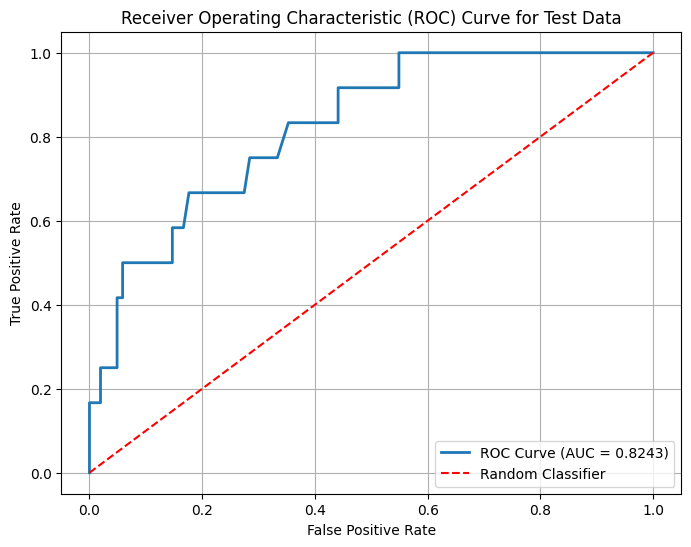

In [12]:
# Testing XGBoost, Bagging

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, roc_curve, confusion_matrix, accuracy_score, precision_score, recall_score

# Load the Test Dataset
test_df = pd.read_excel('B_Test20_NoLKG_Imputed_NORM_RmvZero.xlsx')

# Separate features and target variable
X_test = test_df.drop('mort in', axis=1)
y_test = test_df['mort in']

# Load the Final Trained Model
bagging_model = joblib.load('F_Calibrated_XGBoost_Bagging_Model.pkl')

# Make Predictions on the Test Set
y_test_pred_proba = bagging_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_pred_proba > 0.1275).astype(int)

# Evaluate the Model on the Test Set
# Calculate AUC for the test set
test_auc = roc_auc_score(y_test, y_test_pred_proba)

# Calculate F1 scores for both classes (0 and 1)
test_f1_0 = f1_score(y_test, y_test_pred, pos_label=0)
test_f1_1 = f1_score(y_test, y_test_pred, pos_label=1)

# Calculate Overall F1 Score
overall_f1 = f1_score(y_test, y_test_pred, zero_division=0)

# Accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

# Sensitivity
sensitivity = recall_score(y_test, y_test_pred, pos_label=1)

# Specificity
specificity = recall_score(y_test, y_test_pred, pos_label=0)

# Precision for class 1
precision = precision_score(y_test, y_test_pred, pos_label=1)

# Youden's Index
youden_index = sensitivity + specificity - 1

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Print the Evaluation Results
print(f'Final Test AUC: {round(test_auc, 4)}')
print(f'Final Test Class 0 F1 Score: {round(test_f1_0, 4)}')
print(f'Final Test Class 1 F1 Score: {round(test_f1_1, 4)}')
print(f'Final Test Overall F1 Score: {round(overall_f1, 4)}')
print(f'Final Test Accuracy: {round(test_accuracy, 4)}')
print(f'Final Test Sensitivity: {round(sensitivity, 4)}')
print(f'Final Test Specificity: {round(specificity, 4)}')
print(f'Final Test Precision: {round(precision, 4)}')
print(f'Final Test Youden\'s Index: {round(youden_index, 4)}')
print(f'Final Test Confusion Matrix: \n{conf_matrix}')

# Plot the ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {test_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')

# Set labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Test Data')
plt.legend(loc="lower right")
plt.grid(True)

# Save plots
plt.savefig("XGBoost CALIB AUROC.png", dpi=600)
plt.savefig('XGBoost CALIB AUROC.svg')

plt.show()

# Traditional Methods

In [14]:
# Threshold Traditional According to Highest Youden

import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold

# Load the training dataset

train_df = pd.read_excel('OTrad_Train80_NoLKG_Imputed_NORM_RmvZero.xlsx')
y_train = train_df['mort in']

# List of traditional model score columns
traditional_models = [
    'rachs', 'abc level', 'abc score', 'stmort category', 'stmort score'
]

# Set up Stratified K-Fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary to store the averaged best threshold and metrics for each model
results = {}

# Loop over each traditional model
for model in traditional_models:
    fold_thresholds = []
    fold_metrics = []

    # Cross-validation loop
    for train_index, test_index in cv.split(train_df, y_train):
        train_fold = train_df.iloc[train_index]
        test_fold = train_df.iloc[test_index]

        # Compute the best threshold on the training fold
        scores_train = train_fold[model]
        y_train_fold = train_fold['mort in']
        thresholds = np.unique(scores_train)

        # Skip if not enough unique values
        if len(thresholds) < 2:
            print(f"Model {model} in fold has insufficient unique values.")
            continue

        best_threshold = None
        best_youden = -np.inf

        # Loop over candidate thresholds to maximize Youden's Index on training fold
        for threshold in thresholds:
            y_pred_train = (scores_train >= threshold).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_train_fold, y_pred_train).ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            youden_index = sensitivity + specificity - 1
            if youden_index > best_youden:
                best_youden = youden_index
                best_threshold = threshold

        fold_thresholds.append(best_threshold)

        # Evaluate on the test fold using the best threshold found from the training fold
        scores_test = test_fold[model]
        y_test = test_fold['mort in']
        y_pred_test = (scores_test >= best_threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
        sensitivity_test = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity_test = tn / (tn + fp) if (tn + fp) > 0 else 0
        youden_index_test = sensitivity_test + specificity_test - 1

        fold_metrics.append({
            'sensitivity': sensitivity_test,
            'specificity': specificity_test,
            'youden_index': youden_index_test
        })

    # Average the best threshold and performance metrics over all folds
    if fold_thresholds and fold_metrics:
        avg_threshold = np.mean(fold_thresholds)
        avg_sensitivity = np.mean([m['sensitivity'] for m in fold_metrics])
        avg_specificity = np.mean([m['specificity'] for m in fold_metrics])
        avg_youden = np.mean([m['youden_index'] for m in fold_metrics])

        results[model] = {
            'Avg Best Threshold (CV)': avg_threshold,
            'Avg Sensitivity (CV)': avg_sensitivity,
            'Avg Specificity (CV)': avg_specificity,
            'Avg Youden’s Index (CV)': avg_youden
        }
    else:
        print(f"Skipping model {model} due to insufficient fold data.")

# Convert the results to a DataFrame for visualization and save to an Excel file
results_df = pd.DataFrame(results).transpose()
results_df.to_excel('HIGHEST YOUDEN_Traditional_thresholds_CV.xlsx')

print(results_df)

                 Avg Best Threshold (CV)  Avg Sensitivity (CV)  \
rachs                           0.500000              0.464444   
abc level                       0.500000              0.737778   
abc score                       0.356000              0.737778   
stmort category                 0.400000              0.757778   
stmort score                    0.130435              0.795556   

                 Avg Specificity (CV)  Avg Youden’s Index (CV)  
rachs                        0.853580                 0.318025  
abc level                    0.642623                 0.380401  
abc score                    0.595679                 0.333457  
stmort category              0.513241                 0.271019  
stmort score                 0.665154                 0.460710  


Metrics for rachs:
Accuracy: 0.8509
Sensitivity: 0.4167
Specificity: 0.9020
Precision: 0.3333
F1 Score: 0.3704
Youden's Index: 0.3186
AUROC: 0.6593
True Negatives: 92, False Positives: 10, False Negatives: 7, True Positives: 5

Metrics for abc level:
Accuracy: 0.7018
Sensitivity: 0.5000
Specificity: 0.7255
Precision: 0.1765
F1 Score: 0.2609
Youden's Index: 0.2255
AUROC: 0.6168
True Negatives: 74, False Positives: 28, False Negatives: 6, True Positives: 6

Metrics for abc score:
Accuracy: 0.7018
Sensitivity: 0.5000
Specificity: 0.7255
Precision: 0.1765
F1 Score: 0.2609
Youden's Index: 0.2255
AUROC: 0.6381
True Negatives: 74, False Positives: 28, False Negatives: 6, True Positives: 6

Metrics for stmort category:
Accuracy: 0.8158
Sensitivity: 0.4167
Specificity: 0.8627
Precision: 0.2632
F1 Score: 0.3226
Youden's Index: 0.2794
AUROC: 0.7288
True Negatives: 88, False Positives: 14, False Negatives: 7, True Positives: 5

Metrics for stmort score:
Accuracy: 0.7895
Sensitivity: 0.4167
Specifi

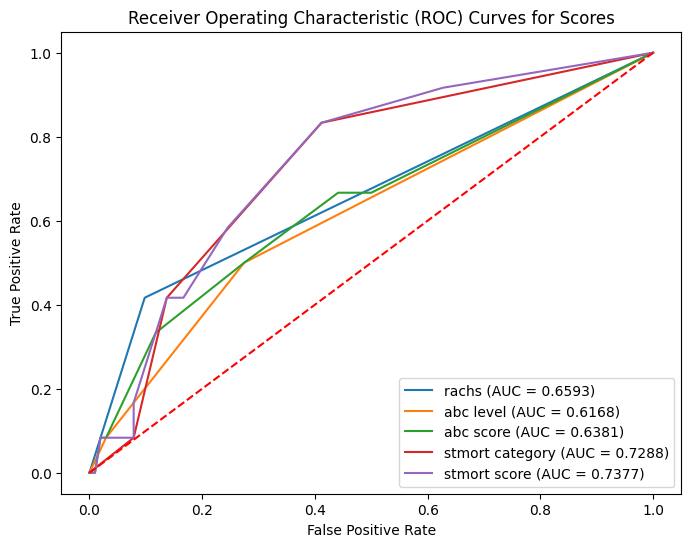

                 Accuracy  Sensitivity  Specificity  Precision  F1 Score  \
rachs            0.850877     0.416667     0.901961   0.333333  0.370370   
abc level        0.701754     0.500000     0.725490   0.176471  0.260870   
abc score        0.701754     0.500000     0.725490   0.176471  0.260870   
stmort category  0.815789     0.416667     0.862745   0.263158  0.322581   
stmort score     0.789474     0.416667     0.833333   0.227273  0.294118   

                 Youden's Index     AUROC  True Negatives  False Positives  \
rachs                  0.318627  0.659314              92               10   
abc level              0.225490  0.616830              74               28   
abc score              0.225490  0.638072              74               28   
stmort category        0.279412  0.728758              88               14   
stmort score           0.250000  0.737745              85               17   

                 False Negatives  True Positives  
rachs                  

In [15]:
# Traditional Testing on test dataset using chosen threhsold

import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt

# Load the test dataset
test_df = pd.read_excel('OTrad_Test20_NoLKG_Imputed_NORM_RmvZero.xlsx')
X_test = test_df.drop('mort in', axis=1)
y_test = test_df['mort in']

# List of score column names to evaluate
score_columns = [
    'rachs', 'abc level', 'abc score', 'stmort category', 'stmort score'
]

# Define specific thresholds for each score column
thresholds = {
    # Youden
    'rachs': 0.5,
    'abc level': 0.5,
    'abc score': 0.356,
    'stmort category': 0.4,
    'stmort score': 0.130434782608696
}

# Initialize a dictionary to store metrics for each score
all_metrics = {}

plt.figure(figsize=(8, 6))

# Function to calculate metrics and plot ROC
def evaluate_model(score_column, y_pred_proba, threshold):
    # Calculate the predicted class using the specific threshold
    y_pred = (y_pred_proba >= threshold).astype(int)

    # Calculate confusion matrix components once
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    sensitivity = recall_score(y_test, y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_test, y_pred, zero_division=0)
    youden_index = sensitivity + specificity - 1
    auc = roc_auc_score(y_test, y_pred_proba)

    # Save metrics for the current score column
    all_metrics[score_column] = {
        'Accuracy': accuracy,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'Precision': precision,
        'F1 Score': f1,
        'Youden\'s Index': youden_index,
        'AUROC': auc,
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp
    }

    # Print the metrics for the current score column
    print(f"Metrics for {score_column}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Youden's Index: {youden_index:.4f}")
    print(f"AUROC: {auc:.4f}")
    print(f"True Negatives: {tn}, False Positives: {fp}, False Negatives: {fn}, True Positives: {tp}\n")

    # Calculate and plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{score_column} (AUC = {auc:.4f})')


# Loop through each score column to evaluate
for score_column in score_columns:
    # Assuming these score columns contain probabilities or raw scores
    y_pred_proba = test_df[score_column]

    # Get the specific threshold for the current score column
    threshold = thresholds[score_column]

    # Call the function to evaluate and plot ROC
    evaluate_model(score_column, y_pred_proba, threshold)

# Plot configuration
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves for Scores')
plt.legend(loc="lower right")

# Save the ROC plot in a vector format for later merging
plt.savefig("Traditional_AUROC.png", dpi=600)
plt.savefig('Traditional_AUROC.svg')
plt.show()

# Convert the metrics dictionary to a DataFrame for easier analysis
metrics_df = pd.DataFrame.from_dict(all_metrics, orient='index')
metrics_df.to_csv('DEFAULT_Youden_Traditional_metrics.csv')

# Print the results
print(metrics_df)


In [ ]:
# Reversing the traditional thresholds to before normalization

import joblib, numpy as np, pandas as pd

# 1) Load the fitted scaler
scaler = joblib.load("NoLKG_SCALER.joblib")

# 2) Normalized thresholds you reported (Youden on normalized features)
thr_norm = pd.Series({
    "rachs": 0.5,
    "abc level": 0.5,
    "abc score": 0.356,
    "stmort category": 0.4,
    "stmort score": 0.130434782608696,
    # model threshold (probability) is already raw, don't invert:
    # "xgb_model_proba": 0.1275
})

# 3) Determine the feature order used by the scaler
if hasattr(scaler, "feature_names_in_"):
    cols = list(scaler.feature_names_in_)
else:
    # Fallback: you must supply the original training column order
    # cols = [...]
    raise ValueError("scaler.feature_names_in_ is missing; provide the training column order in 'cols'.")

# 4) Invert each threshold back to raw units
rows = []
for feat, z in thr_norm.items():
    if feat not in cols:
        rows.append((feat, z, np.nan, "feature not in scaler"))
        continue
    i = cols.index(feat)
    # Create a single sample in normalized space with the threshold only in that feature
    x_norm = np.zeros((1, len(cols)))
    x_norm[0, i] = z
    # Inverse-transform back to raw space
    x_raw = scaler.inverse_transform(x_norm)
    raw_cutoff = float(x_raw[0, i])
    rows.append((feat, z, raw_cutoff, ""))

out = pd.DataFrame(rows, columns=["feature", "threshold_norm", "threshold_raw", "note"])

# 5) For ordinal category features, propose a human-readable cutoff
category_ranges = {
    "rachs": (1, 6),
    "abc level": (1, 5),
    "stmort category": (1, 5),
}
def to_category_cutoff(r):
    if r["feature"] not in category_ranges or pd.isna(r["threshold_raw"]):
        return None
    lo, hi = category_ranges[r["feature"]]
    # Use ceiling to express "≥ category"
    cat = int(np.ceil(r["threshold_raw"]))
    return max(lo, min(cat, hi))

out["recommended_category_cutoff"] = out.apply(to_category_cutoff, axis=1)

print(out)


           feature  threshold_norm  threshold_raw note  \
0            rachs        0.500000           3.00        
1        abc level        0.500000           3.00        
2        abc score        0.356000           7.78        
3  stmort category        0.400000           2.20        
4     stmort score        0.130435           0.50        

   recommended_category_cutoff  
0                          3.0  
1                          3.0  
2                          NaN  
3                          3.0  
4                          NaN  


c:\Users\islmo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


# SHAP Analysis

In [16]:
# SHAP Global Explanation

import pandas as pd
import shap
import joblib
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.ensemble import BaggingClassifier

# Load Training Data
train_df = pd.read_excel('B_Train80_NoLKG_Imputed_NORM_RmvZero.xlsx')
X_train = train_df.drop('mort in', axis=1)
y_train = train_df['mort in']

# Reconstruct the XGBoost Model
def create_xgb_model():
    return xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=42,
        max_depth=3,
        learning_rate=0.01928044904842136,
        min_child_weight=1,
        subsample=0.8614501903065227,
        colsample_bytree=0.8796696936441701,
        colsample_bylevel=0.7324794662581371,
        gamma=1.193696245915529,
        n_estimators=100,
        scale_pos_weight=5,
        reg_alpha=0.00032536986825252743,
        reg_lambda=0.5447906698870625
    )

# Reconstruct and Refit the BaggingClassifier
print("Re-training BaggingClassifier for SHAP...")
bagging_model = BaggingClassifier(
    estimator=create_xgb_model(),
    n_estimators=12,
    max_samples=0.9106169555339139,
    max_features=0.862727747704497,
    bootstrap=True,
    random_state=42
)

bagging_model.fit(X_train, y_train)
print("Model re-trained.")

# Compute SHAP Values
shap_values_all = []

print("Computing SHAP values for each base estimator...")

for i, est in enumerate(bagging_model.estimators_):
    feat_indices = bagging_model.estimators_features_[i]
    X_subset = X_train.iloc[:, feat_indices]

    explainer = shap.TreeExplainer(est)
    shap_vals = explainer.shap_values(X_subset)

    padded = np.zeros((X_train.shape[0], X_train.shape[1]))
    padded[:, feat_indices] = shap_vals
    shap_values_all.append(padded)

    print(f"Estimator {i + 1}/{len(bagging_model.estimators_)} processed.")

# Average SHAP Values
print("Averaging SHAP values across all estimators...")
shap_values_mean = np.mean(shap_values_all, axis=0)

# Rename Features for Readability
custom_titles = {
    'weight': 'Weight',
    'stmort score': 'STS-EACTS Mortality Score',
    'spo2': 'SpO2',
    'abc score': 'ABC Score',
    'hct': 'HCT',
    'age': 'Age',
    'hb': 'Hemoglobin',
    'stmort category': 'STS-EACTS Mortality Category',
    'mcv': 'MCV',
    'inr': 'INR'
}
X_train_renamed = X_train.rename(columns=custom_titles)

# Generate SHAP Summary Plot
print("Generating SHAP summary plot...")
plt.figure()
shap.summary_plot(shap_values_mean, X_train_renamed, show=False, max_display=10)
plt.savefig('Calibrated_Bagging_SHAP_Summary.png', dpi=600, bbox_inches='tight')
plt.close()

# Export Mean Absolute SHAP Values
print("Saving SHAP feature importances...")
mean_abs_shap = pd.DataFrame({
    'Feature': X_train.columns,
    'Mean_Absolute_SHAP': np.abs(shap_values_mean).mean(axis=0)
}).sort_values(by='Mean_Absolute_SHAP', ascending=False)

mean_abs_shap.to_excel('Calibrated_Bagging_SHAP_Importances.xlsx', index=False)
print("SHAP feature importances saved.")


Re-training BaggingClassifier for SHAP...
Model re-trained.
Computing SHAP values for each base estimator...
Estimator 1/12 processed.
Estimator 2/12 processed.
Estimator 3/12 processed.
Estimator 4/12 processed.
Estimator 5/12 processed.
Estimator 6/12 processed.
Estimator 7/12 processed.
Estimator 8/12 processed.
Estimator 9/12 processed.
Estimator 10/12 processed.
Estimator 11/12 processed.
Estimator 12/12 processed.
Averaging SHAP values across all estimators...
Generating SHAP summary plot...
Saving SHAP feature importances...
SHAP feature importances saved.


Re-fitting BaggingClassifier...
Model re-trained.
Patient Index: 1
Predicted Probability of Mortality: 0.1257
Predicted Outcome (Threshold = 0.1275): Survival (0)
True Label: Survival (0)


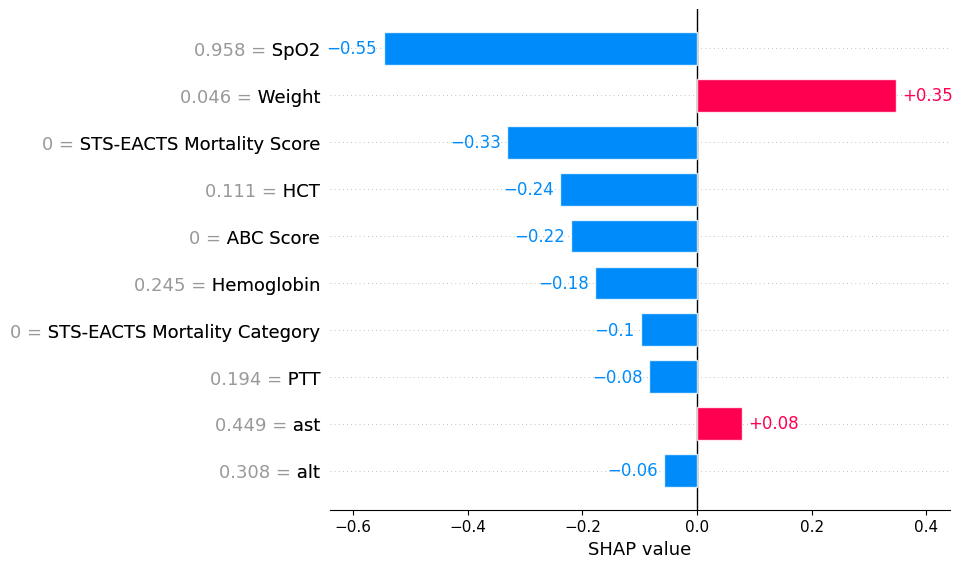

SHAP bar plot saved as: SHAP_Bar_Patient_Top10.png


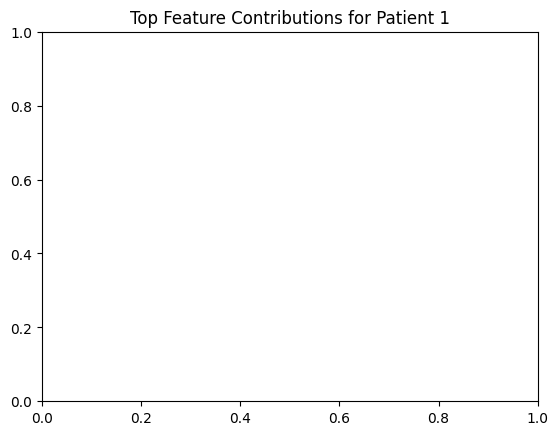

In [17]:
# SHAP Per-Patient Explanation

import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.ensemble import BaggingClassifier

# Load datasets
X_train_full = pd.read_excel('B_Train80_NoLKG_Imputed_NORM_RmvZero.xlsx')
X_test_full = pd.read_excel('B_Test20_NoLKG_Imputed_NORM_RmvZero.xlsx')

# Separate features and target
X_train = X_train_full.drop('mort in', axis=1)
y_train = X_train_full['mort in']
X_test = X_test_full.drop('mort in', axis=1)
y_test = X_test_full['mort in']
X_test = X_test[X_train.columns]

# Reconstruct and fit Bagging model (uncalibrated)
def create_xgb_model():
    return xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=42,
        max_depth=3,
        learning_rate=0.01928044904842136,
        min_child_weight=1,
        subsample=0.8614501903065227,
        colsample_bytree=0.8796696936441701,
        colsample_bylevel=0.7324794662581371,
        gamma=1.193696245915529,
        n_estimators=100,
        scale_pos_weight=5,
        reg_alpha=0.00032536986825252743,
        reg_lambda=0.5447906698870625
    )

print("Re-fitting BaggingClassifier...")
bagging_model = BaggingClassifier(
    estimator=create_xgb_model(),
    n_estimators=12,
    max_samples=0.9106169555339139,
    max_features=0.862727747704497,
    bootstrap=True,
    random_state=42
)
bagging_model.fit(X_train, y_train)
print("Model re-trained.")

# Select patient
instance_index = 0
instance = X_test.iloc[[instance_index]]
custom_threshold = 0.1275
y_pred_proba = bagging_model.predict_proba(instance)[0, 1]
predicted_class = int(y_pred_proba > custom_threshold)
true_label = y_test.iloc[instance_index]

# Output summary
print(f"Patient Index: {instance_index + 1}")
print(f"Predicted Probability of Mortality: {y_pred_proba:.4f}")
print(f"Predicted Outcome (Threshold = {custom_threshold}): {'Mortality (1)' if predicted_class == 1 else 'Survival (0)'}")
print(f"True Label: {'Mortality (1)' if true_label == 1 else 'Survival (0)'}")

# Compute SHAP values for the instance
shap_values_per_estimator = []

for i, est in enumerate(bagging_model.estimators_):
    feat_indices = bagging_model.estimators_features_[i]
    feat_names = X_train.columns[feat_indices]
    instance_subset = instance[feat_names]

    explainer = shap.TreeExplainer(est)
    shap_val = explainer.shap_values(instance_subset)

    padded = np.zeros((1, X_test.shape[1]))
    padded[:, feat_indices] = shap_val
    shap_values_per_estimator.append(padded)

# Average SHAP values and base value
shap_values_avg = np.mean(shap_values_per_estimator, axis=0).flatten()
expected_values = [shap.TreeExplainer(est).expected_value for est in bagging_model.estimators_]
expected_value_avg = np.mean(expected_values)

# Rename columns
custom_titles = {
    'weight': 'Weight',
    'stmort score': 'STS-EACTS Mortality Score',
    'spo2': 'SpO2',
    'abc score': 'ABC Score',
    'hct': 'HCT',
    'age': 'Age',
    'hb': 'Hemoglobin',
    'stmort category': 'STS-EACTS Mortality Category',
    'mcv': 'MCV',
    'inr': 'INR',
    'rachs': 'RACHS-1 Category',
    'urea': 'Urea',
    'ptt': 'PTT',
    'plt': 'Platelets'
}
instance_renamed = instance.rename(columns={k: v for k, v in custom_titles.items() if k in instance.columns})

# Build SHAP dataframe
shap_df = pd.DataFrame({
    'feature': instance_renamed.columns,
    'value': instance_renamed.iloc[0].round(3),
    'shap_value': shap_values_avg
})
shap_df_sorted = shap_df.reindex(shap_df.shap_value.abs().sort_values(ascending=False).index)
shap_df_top = shap_df_sorted.head(10)

# SHAP Explanation Object
explanation = shap.Explanation(
    values=shap_df_top['shap_value'].values,
    base_values=expected_value_avg,
    data=shap_df_top['value'].values,
    feature_names=shap_df_top['feature'].values
)

# Plot and Save
fig = plt.figure()
shap.plots.bar(explanation, max_display=10)
plt.title(f"Top Feature Contributions for Patient {instance_index + 1}")
fig.savefig("SHAP_Bar_Patient_Top10.png", dpi=600, bbox_inches='tight')
fig.savefig("SHAP_Bar_Patient_Alt.png", dpi=600, bbox_inches='tight')
plt.close(fig)

print("SHAP bar plot saved as: SHAP_Bar_Patient_Top10.png")


Re-fitting BaggingClassifier...
Model re-trained.
Patient Index: 1
Predicted Probability of Mortality: 0.1200
True Label: Survival (0)


C:\Users\islmo\AppData\Local\Temp\ipykernel_10604\1205485090.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_prob = float(bagging_model.predict_proba(instance)[:, 1])


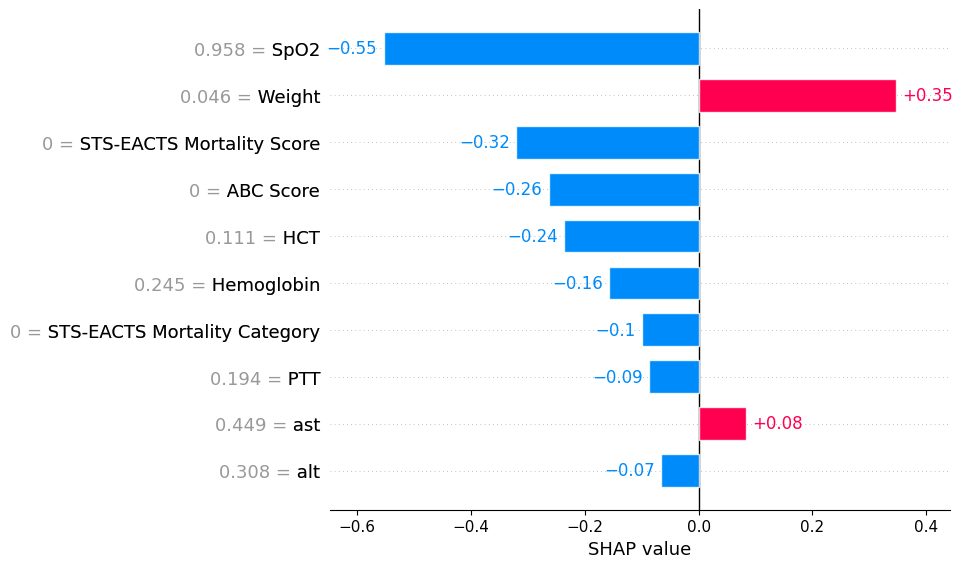

SHAP bar plot saved as: SHAP_Bar_Patient_Top10.png


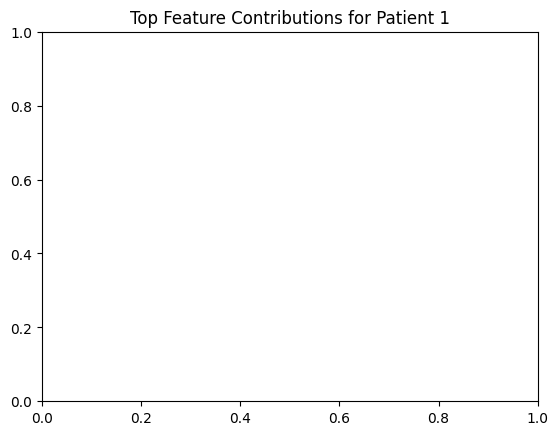

In [ ]:
# SHAP Per-Patient Explanation: UPDATED TO SHOW PROBABILITY

import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.ensemble import BaggingClassifier

# Load datasets
X_train_full = pd.read_excel('B_Train80_NoLKG_Imputed_NORM_RmvZero.xlsx')
X_test_full = pd.read_excel('B_Test20_NoLKG_Imputed_NORM_RmvZero.xlsx')

# Separate features and target
X_train = X_train_full.drop('mort in', axis=1)
y_train = X_train_full['mort in']
X_test = X_test_full.drop('mort in', axis=1)
y_test = X_test_full['mort in']
X_test = X_test[X_train.columns]

# Reconstruct and fit Bagging model (uncalibrated)
def create_xgb_model():
    return xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=42,
        max_depth=3,
        learning_rate=0.01928044904842136,
        min_child_weight=1,
        subsample=0.8614501903065227,
        colsample_bytree=0.8796696936441701,
        colsample_bylevel=0.7324794662581371,
        gamma=1.193696245915529,
        n_estimators=100,
        scale_pos_weight=5,
        reg_alpha=0.00032536986825252743,
        reg_lambda=0.5447906698870625
    )

print("Re-fitting BaggingClassifier...")
bagging_model = BaggingClassifier(
    estimator=create_xgb_model(),
    n_estimators=12,
    max_samples=0.9106169555339139,
    max_features=0.862727747704497,
    bootstrap=True,
    random_state=42
)
bagging_model.fit(X_train, y_train)
print("Model re-trained.")

# Select patient
instance_index = 0
instance = X_test.iloc[[instance_index]]
true_label = y_test.iloc[instance_index]

# CHANGED: get probability only (no thresholding)
y_prob = float(bagging_model.predict_proba(instance)[:, 1])

# Output summary
print(f"Patient Index: {instance_index + 1}")
print(f"Predicted Probability of Mortality: {y_prob:.4f}")
print(f"True Label: {'Mortality (1)' if true_label == 1 else 'Survival (0)'}")

# Compute SHAP values for the instance
shap_values_per_estimator = []

for i, est in enumerate(bagging_model.estimators_):
    feat_indices = bagging_model.estimators_features_[i]
    feat_names = X_train.columns[feat_indices]
    instance_subset = instance[feat_names]

    explainer = shap.TreeExplainer(est)
    shap_val = explainer.shap_values(instance_subset)

    padded = np.zeros((1, X_test.shape[1]))
    padded[:, feat_indices] = shap_val
    shap_values_per_estimator.append(padded)

# Average SHAP values and base value
shap_values_avg = np.mean(shap_values_per_estimator, axis=0).flatten()
expected_values = [shap.TreeExplainer(est).expected_value for est in bagging_model.estimators_]
expected_value_avg = np.mean(expected_values)

# Rename columns
custom_titles = {
    'weight': 'Weight',
    'stmort score': 'STS-EACTS Mortality Score',
    'spo2': 'SpO2',
    'abc score': 'ABC Score',
    'hct': 'HCT',
    'age': 'Age',
    'hb': 'Hemoglobin',
    'stmort category': 'STS-EACTS Mortality Category',
    'mcv': 'MCV',
    'inr': 'INR',
    'rachs': 'RACHS-1 Category',
    'urea': 'Urea',
    'ptt': 'PTT',
    'plt': 'Platelets'
}
instance_renamed = instance.rename(columns={k: v for k, v in custom_titles.items() if k in instance.columns})

# Build SHAP dataframe
shap_df = pd.DataFrame({
    'feature': instance_renamed.columns,
    'value': instance_renamed.iloc[0].round(3),
    'shap_value': shap_values_avg
})
shap_df_sorted = shap_df.reindex(shap_df.shap_value.abs().sort_values(ascending=False).index)
shap_df_top = shap_df_sorted.head(10)

# SHAP Explanation Object
explanation = shap.Explanation(
    values=shap_df_top['shap_value'].values,
    base_values=expected_value_avg,
    data=shap_df_top['value'].values,
    feature_names=shap_df_top['feature'].values
)

# Plot and Save
fig = plt.figure()
shap.plots.bar(explanation, max_display=10)
plt.title(f"Top Feature Contributions for Patient {instance_index + 1}")
fig.savefig("SHAP_Bar_Patient_Top10.png", dpi=600, bbox_inches='tight')
fig.savefig("SHAP_Bar_Patient_Alt.png", dpi=600, bbox_inches='tight')
plt.close(fig)

print("SHAP bar plot saved as: SHAP_Bar_Patient_Top10.png")


c:\Users\islmo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator BaggingClassifier from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\islmo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator IsotonicRegression from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\islmo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle 

Patient Index: 11
Predicted Probability of Mortality: 0.0000
True Label: Survival (0)


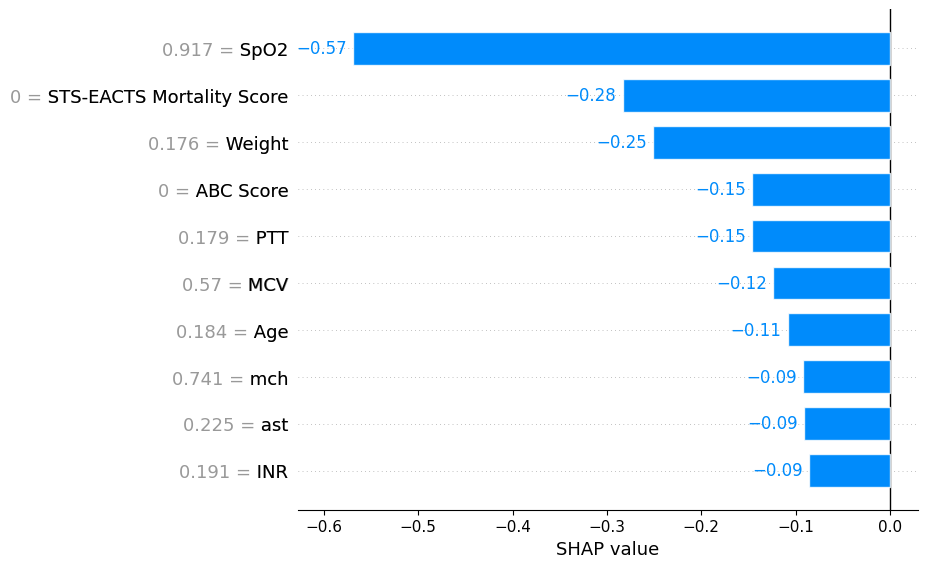

SHAP bar plot saved as: SHAP_Bar_Patient_Top10.png


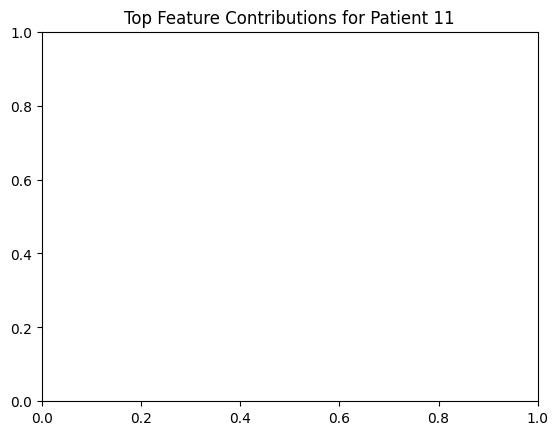

In [ ]:
# SHAP Per-Patient Explanation: UPDATED TO USE SAVED MODEL

import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import BaggingClassifier
from sklearn.calibration import CalibratedClassifierCV

# -------------------------------------------------------
# Load test dataset (already imputed + normalized version)
# -------------------------------------------------------
X_test_full = pd.read_excel('B_Test20_NoLKG_Imputed_NORM_RmvZero.xlsx')
X_test = X_test_full.drop('mort in', axis=1)
y_test = X_test_full['mort in']

# Separate features and target
X_train = X_train_full.drop('mort in', axis=1)
y_train = X_train_full['mort in']
X_test = X_test_full.drop('mort in', axis=1)
y_test = X_test_full['mort in']
X_test = X_test[X_train.columns]

# -------------------------------------------------------
# Load your trained + calibrated model
# -------------------------------------------------------
model = joblib.load("F_Calibrated_XGBoost_Bagging_Model.pkl")

# Get probability from calibrated model
instance_index = 10
instance = X_test.iloc[[instance_index]]
true_label = y_test.iloc[instance_index]
y_prob = float(model.predict_proba(instance)[:, 1])

print(f"Patient Index: {instance_index + 1}")
print(f"Predicted Probability of Mortality: {y_prob:.4f}")
print(f"True Label: {'Mortality (1)' if true_label == 1 else 'Survival (0)'}")

# -------------------------------------------------------
# Unwrap the calibrated model for SHAP
# -------------------------------------------------------
def unwrap_for_shap(m):
    """Get the underlying tree model for SHAP if wrapped in calibration."""
    if isinstance(m, CalibratedClassifierCV):
        if hasattr(m, "calibrated_classifiers_") and m.calibrated_classifiers_:
            inner = m.calibrated_classifiers_[0]
            if hasattr(inner, "estimator"):
                return inner.estimator
        if hasattr(m, "base_estimator"):
            return m.base_estimator
    return m

shap_model = unwrap_for_shap(model)

# -------------------------------------------------------
# Compute SHAP values
# -------------------------------------------------------
shap_values_per_estimator = []
expected_values = []

if isinstance(shap_model, BaggingClassifier):
    for i, est in enumerate(shap_model.estimators_):
        feat_indices = shap_model.estimators_features_[i]
        feat_names = X_train.columns[feat_indices]
        instance_subset = instance[feat_names]

        explainer = shap.TreeExplainer(est)
        shap_val = explainer.shap_values(instance_subset)

        padded = np.zeros((1, X_test.shape[1]))
        padded[:, feat_indices] = shap_val
        shap_values_per_estimator.append(padded)

        expected_values.append(explainer.expected_value)

    shap_values_avg = np.mean(shap_values_per_estimator, axis=0).flatten()
    expected_value_avg = np.mean(expected_values)

else:
    explainer = shap.TreeExplainer(shap_model)
    shap_values_avg = explainer.shap_values(instance).flatten()
    expected_value_avg = explainer.expected_value

# -------------------------------------------------------
# Build SHAP dataframe
# -------------------------------------------------------
custom_titles = {
    'weight': 'Weight',
    'stmort score': 'STS-EACTS Mortality Score',
    'spo2': 'SpO2',
    'abc score': 'ABC Score',
    'hct': 'HCT',
    'age': 'Age',
    'hb': 'Hemoglobin',
    'stmort category': 'STS-EACTS Mortality Category',
    'mcv': 'MCV',
    'inr': 'INR',
    'rachs': 'RACHS-1 Category',
    'urea': 'Urea',
    'ptt': 'PTT',
    'plt': 'Platelets'
}

instance_renamed = instance.rename(
    columns={k: v for k, v in custom_titles.items() if k in instance.columns}
)

shap_df = pd.DataFrame({
    'feature': instance_renamed.columns,
    'value': instance_renamed.iloc[0].round(3),
    'shap_value': shap_values_avg
})
shap_df_sorted = shap_df.reindex(
    shap_df.shap_value.abs().sort_values(ascending=False).index
)
shap_df_top = shap_df_sorted.head(10)

# -------------------------------------------------------
# SHAP Explanation Object and Plot
# -------------------------------------------------------
explanation = shap.Explanation(
    values=shap_df_top['shap_value'].values,
    base_values=expected_value_avg,
    data=shap_df_top['value'].values,
    feature_names=shap_df_top['feature'].values
)

fig = plt.figure()
shap.plots.bar(explanation, max_display=10)
plt.title(f"Top Feature Contributions for Patient {instance_index + 1}")
fig.savefig("SHAP_Bar_Patient_Top10.png", dpi=600, bbox_inches='tight')
fig.savefig("SHAP_Bar_Patient_Alt.png", dpi=600, bbox_inches='tight')
plt.close(fig)

print("SHAP bar plot saved as: SHAP_Bar_Patient_Top10.png")


In [1]:
import sys
import platform
import importlib
import subprocess

LIBRARIES = [
    "sklearn",
    "xgboost",
    "numpy",
    "pandas",
    "matplotlib",
    "joblib",
    "shap",
    "openpyxl",
    "streamlit",
]

# ================================
# PYTHON INFO
# ================================
print("===== PYTHON EXECUTION INFO =====")
print("Python executable :", sys.executable)
print("Python version    :", sys.version)
print("Platform          :", platform.platform())
print("Environment path  :", sys.prefix)
print()

# ================================
# PIP INFO
# ================================
print("===== PIP INFO =====")
try:
    pip_info = subprocess.check_output(
        [sys.executable, "-m", "pip", "-V"],
        text=True
    ).strip()
    print(pip_info)
except Exception as e:
    print("Could not determine pip version:", e)
print()

# ================================
# LIBRARY VERSIONS
# ================================
print("===== INSTALLED LIBRARY VERSIONS =====")

for lib in LIBRARIES:
    try:
        module = importlib.import_module(lib)
        version = getattr(module, "__version__", "Unknown")
        print(f"{lib:<15}: {version}")
    except Exception as e:
        print(f"{lib:<15}: NOT INSTALLED")

print("\n===== CHECK COMPLETE =====")

===== PYTHON EXECUTION INFO =====
Python executable : c:\Users\islmo\AppData\Local\Programs\Python\Python312\python.exe
Python version    : 3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]
Platform          : Windows-11-10.0.26200-SP0
Environment path  : c:\Users\islmo\AppData\Local\Programs\Python\Python312

===== PIP INFO =====
pip 26.0.1 from c:\Users\islmo\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip (python 3.12)

===== INSTALLED LIBRARY VERSIONS =====
sklearn        : 1.6.1
xgboost        : 3.2.0
numpy          : 2.0.2
pandas         : 2.2.2
matplotlib     : 3.10.0
joblib         : 1.5.3


C:\Users\islmo\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap           : 0.50.0
openpyxl       : 3.1.5
streamlit      : 1.54.0

===== CHECK COMPLETE =====


# Traditional With Variables

In [18]:
# Finding Thresholds Using Youden Index

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve
import joblib
import os

# Load the correct training dataset
train_df = pd.read_excel("B_Train80_NoLKG_Imputed_NORM_RmvZero.xlsx")

# Output directory for models and thresholds
output_dir = "trad_models"
os.makedirs(output_dir, exist_ok=True)

# Target column
target_col = "mort in"

# All traditional models
all_scores = ['rachs', 'abc score', 'stmort score', 'abc level', 'stmort category']

# Final model features
final_features = [
    'weight', 'stmort score', 'spo2', 'abc score', 'hct', 'age', 'hb',
    'stmort category', 'mcv', 'inr', 'mchc', 'ptt', 'mch', 'urea', 'rachs',
    'alt', 'plt', 'tlc', 'ast', 'creat', 'abc level', 'cavc repair',
    'rv infundibulectomy', 'tof rv to pa conduit', 'gender', 'downs'
]

# Store optimal thresholds
thresholds = {}

# Train and evaluate logistic models
for score_name in all_scores:
    print(f"\nTraining model for: {score_name}")

    X_train = train_df[final_features]
    y_train = train_df[target_col]

    # Train logistic regression model
    clf = LogisticRegression(solver='liblinear', max_iter=1000)
    clf.fit(X_train, y_train)

    # Predict probabilities
    y_probs = clf.predict_proba(X_train)[:, 1]

    # Compute ROC curve
    fpr, tpr, threshold_vals = roc_curve(y_train, y_probs)
    specificity = 1 - fpr

    # Compute Youden Index
    youden_index = tpr + specificity - 1
    optimal_threshold = threshold_vals[np.argmax(youden_index)]
    thresholds[score_name] = optimal_threshold

    # Save model and threshold
    model_path = os.path.join(output_dir, f"{score_name}_logreg_model.pkl")
    threshold_path = os.path.join(output_dir, f"{score_name}_threshold.txt")

    joblib.dump(clf, model_path)
    with open(threshold_path, "w") as f:
        f.write(str(optimal_threshold))

    print(f"Saved model and threshold for {score_name} (Youden Threshold: {optimal_threshold:.4f})")

print("\nAll five traditional models trained and saved using Youden Index thresholds.")



Training model for: rachs
Saved model and threshold for rachs (Youden Threshold: 0.1125)

Training model for: abc score
Saved model and threshold for abc score (Youden Threshold: 0.1125)

Training model for: stmort score
Saved model and threshold for stmort score (Youden Threshold: 0.1125)

Training model for: abc level
Saved model and threshold for abc level (Youden Threshold: 0.1125)

Training model for: stmort category
Saved model and threshold for stmort category (Youden Threshold: 0.1125)

All five traditional models trained and saved using Youden Index thresholds.


In [19]:
# Testing Traditional

import pandas as pd
import numpy as np
import joblib
import os
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, roc_auc_score,
    confusion_matrix
)

# Load the test dataset
test_df = pd.read_excel("B_Test20_NoLKG_Imputed_NORM_RmvZero.xlsx")
target_col = "mort in"

# Directory where the models are stored
model_dir = "trad_models"

# Traditional scores
all_scores = ['rachs', 'abc score', 'stmort score', 'abc level', 'stmort category']

# Features used during training
final_features = [
    'weight', 'stmort score', 'spo2', 'abc score', 'hct', 'age', 'hb',
    'stmort category', 'mcv', 'inr', 'mchc', 'ptt', 'mch', 'urea', 'rachs',
    'alt', 'plt', 'tlc', 'ast', 'creat', 'abc level', 'cavc repair',
    'rv infundibulectomy', 'tof rv to pa conduit', 'gender', 'downs'
]

# Fixed threshold used for all traditional models
fixed_threshold = 0.1125

# Specificity calculation
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

# Youden index
def youden_index(sens, spec):
    return sens + spec - 1

# Store results
results = []

# Evaluate each model
for score in all_scores:
    print(f"\nEvaluating: {score}")

    # Load model
    model_path = os.path.join(model_dir, f"{score}_logreg_model.pkl")
    clf = joblib.load(model_path)

    # Prepare test data
    X_test = test_df[final_features]
    y_true = test_df[target_col]

    # Predict and classify
    y_probs = clf.predict_proba(X_test)[:, 1]
    y_pred = (y_probs >= fixed_threshold).astype(int)

    # Compute metrics
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred)
    spec = specificity_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_probs)
    youden = youden_index(sens, spec)
    cm = confusion_matrix(y_true, y_pred)

    # Print to console
    print(f"Threshold     : {fixed_threshold:.4f}")
    print(f"Accuracy      : {acc:.4f}")
    print(f"Sensitivity   : {sens:.4f}")
    print(f"Specificity   : {spec:.4f}")
    print(f"Precision     : {prec:.4f}")
    print(f"F1 Score      : {f1:.4f}")
    print(f"Youden Index  : {youden:.4f}")
    print(f"AUROC         : {auc:.4f}")
    print("Confusion Matrix:")
    print(cm)

    # Save results
    results.append({
        "Model": score,
        "Threshold": fixed_threshold,
        "Accuracy": acc,
        "Sensitivity": sens,
        "Specificity": spec,
        "Precision": prec,
        "F1 Score": f1,
        "Youden Index": youden,
        "AUROC": auc,
        "Confusion Matrix": cm.tolist()
    })

# Save to Excel
results_df = pd.DataFrame(results)
results_df.to_excel("Traditional_Logistic_Test_Results_FixedThreshold.xlsx", index=False)
print("\nEvaluation completed and results saved to Excel.")



Evaluating: rachs
Threshold     : 0.1125
Accuracy      : 0.8070
Sensitivity   : 0.5833
Specificity   : 0.8333
Precision     : 0.2917
F1 Score      : 0.3889
Youden Index  : 0.4167
AUROC         : 0.7868
Confusion Matrix:
[[85 17]
 [ 5  7]]

Evaluating: abc score
Threshold     : 0.1125
Accuracy      : 0.8070
Sensitivity   : 0.5833
Specificity   : 0.8333
Precision     : 0.2917
F1 Score      : 0.3889
Youden Index  : 0.4167
AUROC         : 0.7868
Confusion Matrix:
[[85 17]
 [ 5  7]]

Evaluating: stmort score
Threshold     : 0.1125
Accuracy      : 0.8070
Sensitivity   : 0.5833
Specificity   : 0.8333
Precision     : 0.2917
F1 Score      : 0.3889
Youden Index  : 0.4167
AUROC         : 0.7868
Confusion Matrix:
[[85 17]
 [ 5  7]]

Evaluating: abc level
Threshold     : 0.1125
Accuracy      : 0.8070
Sensitivity   : 0.5833
Specificity   : 0.8333
Precision     : 0.2917
F1 Score      : 0.3889
Youden Index  : 0.4167
AUROC         : 0.7868
Confusion Matrix:
[[85 17]
 [ 5  7]]

Evaluating: stmort categ

# External Validation

In [23]:
# Imputation like test dataset

import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

# Load training and test datasets
train_path = "ExtVal_B_Train80_NoLKG_26.xlsx"
test_path = "ExtVal_Combined (116)_Cleaned_3_After Dealing with Outliers.xlsx"
train_df = pd.read_excel(train_path)
test_df = pd.read_excel(test_path)

# Define target column (to exclude from imputation)
target_col = "mortin"

# Identify numeric columns with missing values (excluding target)
num_cols = train_df.select_dtypes(include=['float64', 'int64']).columns
impute_cols = [col for col in num_cols if col != target_col and (train_df[col].isnull().sum() > 0 or test_df[col].isnull().sum() > 0)]

# Display missing value counts before imputation
print("Missing values before imputation (Training):")
print(train_df[impute_cols].isnull().sum())
print("\nMissing values before imputation (Testing):")
print(test_df[impute_cols].isnull().sum())

# Initialize Random Forest Regressor-based imputer
imputer = IterativeImputer(estimator=RandomForestRegressor(n_estimators=100, random_state=42),
                           max_iter=10, random_state=42)

# Fit imputer on training data only
imputer.fit(train_df[impute_cols])

# Transform both training and test sets
train_df[impute_cols] = imputer.transform(train_df[impute_cols])
test_df[impute_cols] = imputer.transform(test_df[impute_cols])

# Define rounding rules
rounding_dict = {
    "ones": ["spo2", "urea"],
    "tenths": ["weight", "hct"],
    "hundredths": ["creat"]
}

# Apply rounding
for col in rounding_dict["ones"]:
    for df in [train_df, test_df]:
        if col in df.columns:
            df[col] = df[col].round(0).astype(int)

for col in rounding_dict["tenths"]:
    for df in [train_df, test_df]:
        if col in df.columns:
            df[col] = df[col].round(1)

for col in rounding_dict["hundredths"]:
    for df in [train_df, test_df]:
        if col in df.columns:
            df[col] = df[col].round(2)

# Display missing value counts after imputation
print("\nMissing values after imputation (Training):")
print(train_df[impute_cols].isnull().sum())
print("\nMissing values after imputation (Testing):")
print(test_df[impute_cols].isnull().sum())

# Save the imputed datasets
train_df.to_excel("NOTNEEDED_Train80_NoLKG_Imputed.xlsx", index=False)
test_df.to_excel("ExtVal_Combined (116)_Cleaned_4_Imputed.xlsx", index=False)
print("\nImputed datasets saved.")

Missing values before imputation (Training):
weight     3
spo2      78
hct        0
mcv        2
inr       12
ptt       55
creat      9
urea      15
alt       38
ast       50
dtype: int64

Missing values before imputation (Testing):
weight    1
spo2      5
hct       1
mcv       0
inr       0
ptt       0
creat     1
urea      2
alt       0
ast       0
dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(



Missing values after imputation (Training):
weight    0
spo2      0
hct       0
mcv       0
inr       0
ptt       0
creat     0
urea      0
alt       0
ast       0
dtype: int64

Missing values after imputation (Testing):
weight    0
spo2      0
hct       0
mcv       0
inr       0
ptt       0
creat     0
urea      0
alt       0
ast       0
dtype: int64

Imputed datasets saved.


In [24]:
# Adding Empty Columns to the External Validation Dataset
# To Use the Scaler of the Training Dataset

import pandas as pd

# Load the reference normalized file and the new test dataset
train_norm = pd.read_excel("ExtVal_B_Train80_NoLKG_Imputed_NORM.xlsx")
new_data = pd.read_excel("ExtVal_Combined (116)_Cleaned_4_Imputed_Added Spaces Titles.xlsx")

# Get list of columns from the normalized training data
train_columns = train_norm.columns.tolist()

# Get list of columns from the new data
new_data_columns = new_data.columns.tolist()

# Find missing columns
missing_cols = [col for col in train_columns if col not in new_data_columns]

# Add missing columns as empty
for col in missing_cols:
    new_data[col] = pd.NA

# Reorder columns to match the training normalized data
new_data = new_data[train_columns]

# Save the updated new dataset
new_data.to_excel("ExtVal_Combined (116)_5_Added Empty Columns For Norm.xlsx", index=False)

print("File saved successfully as 'ExtVal_Combined (116)_5_Added Empty Columns For Norm.xlsx'")


FileNotFoundError: [Errno 2] No such file or directory: 'ExtVal_B_Train80_NoLKG_Imputed_NORM.xlsx'

In [ ]:
# Applying Normalization to the External Validation dataset

import joblib
import pandas as pd

# Load the previously saved Normalization scaler
scaler = joblib.load('ExtVal_NoLKG_SCALER.joblib')

# Load the test or validation dataset
df_test = pd.read_excel('ExtVal_Combined (116)_5_Added Empty Columns For Norm.xlsx')

# Identify the numerical columns
numerical_cols = df_test.select_dtypes(include=['float64', 'int64']).columns

# Apply the scaler to the dataset
df_test[numerical_cols] = scaler.transform(df_test[numerical_cols])

# Save the normalized dataset to a new Excel file
df_test.to_excel('ExtVal_Combined (116)_6_Norm.xlsx', index=False)

print("Normalized dataset saved!")

In [ ]:
# Testing on External Validation Dataset

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, roc_curve, confusion_matrix, accuracy_score, precision_score, recall_score

# Load the Test Dataset
test_df = pd.read_excel('ExtVal_Combined (116)_7_114 12_Removed Columns_Randomed.xlsx')

# Separate features and target variable
X_test = test_df.drop('mort in', axis=1)
y_test = test_df['mort in']

# Load the Final Trained Model
bagging_model = joblib.load('F_Calibrated_XGBoost_Bagging_Model.pkl')

# Make Predictions on the Test Set
y_test_pred_proba = bagging_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_pred_proba > 0.1275).astype(int)

# Evaluate the Model on the Test Set
# Calculate AUC for the test set
test_auc = roc_auc_score(y_test, y_test_pred_proba)

# Calculate F1 scores for both classes (0 and 1)
test_f1_0 = f1_score(y_test, y_test_pred, pos_label=0)
test_f1_1 = f1_score(y_test, y_test_pred, pos_label=1)

# Calculate Overall F1 Score
overall_f1 = f1_score(y_test, y_test_pred, zero_division=0)

# Additional Metrics Calculation

# Accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

# Sensitivity
sensitivity = recall_score(y_test, y_test_pred, pos_label=1)

# Specificity
specificity = recall_score(y_test, y_test_pred, pos_label=0)

# Precision for class 1
precision = precision_score(y_test, y_test_pred, pos_label=1)

# Youden's Index (Sensitivity + Specificity - 1)
youden_index = sensitivity + specificity - 1

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Print the Evaluation Results
print(f'Final Test AUC: {round(test_auc, 4)}')
print(f'Final Test Class 0 F1 Score: {round(test_f1_0, 4)}')
print(f'Final Test Class 1 F1 Score: {round(test_f1_1, 4)}')
print(f'Final Test Overall F1 Score: {round(overall_f1, 4)}')
print(f'Final Test Accuracy: {round(test_accuracy, 4)}')
print(f'Final Test Sensitivity: {round(sensitivity, 4)}')
print(f'Final Test Specificity: {round(specificity, 4)}')
print(f'Final Test Precision: {round(precision, 4)}')
print(f'Final Test Youden\'s Index: {round(youden_index, 4)}')
print(f'Final Test Confusion Matrix: \n{conf_matrix}')

# Plot the ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {test_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')

# Set labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Test Data')
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

In [ ]:
# Traditional Testing on test dataset using chosen threhsold

import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt

# Load the test dataset
test_df = pd.read_excel('ExtVal_Combined (116)_8_114 12_Traditional Only.xlsx')
X_test = test_df.drop('mort in', axis=1)
y_test = test_df['mort in']

# List of score column names to evaluate
score_columns = [
    'rachs', 'abc level', 'abc score', 'stmort category', 'stmort score'
]

# Define specific thresholds for each score column
thresholds = {
    # Youden
    'rachs': 0.5,
    'abc level': 0.5,
    'abc score': 0.356,
    'stmort category': 0.4,
    'stmort score': 0.130434782608696
}

# Initialize a dictionary to store metrics for each score
all_metrics = {}

plt.figure(figsize=(8, 6))

# Function to calculate metrics and plot ROC
def evaluate_model(score_column, y_pred_proba, threshold):
    # Calculate the predicted class using the specific threshold
    y_pred = (y_pred_proba >= threshold).astype(int)

    # Calculate confusion matrix components once
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    sensitivity = recall_score(y_test, y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_test, y_pred, zero_division=0)
    youden_index = sensitivity + specificity - 1
    auc = roc_auc_score(y_test, y_pred_proba)

    # Save metrics for the current score column
    all_metrics[score_column] = {
        'Accuracy': accuracy,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'Precision': precision,
        'F1 Score': f1,
        'Youden\'s Index': youden_index,
        'AUROC': auc,
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp
    }

    # Print the metrics for the current score column
    print(f"Metrics for {score_column}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Youden's Index: {youden_index:.4f}")
    print(f"AUROC: {auc:.4f}")
    print(f"True Negatives: {tn}, False Positives: {fp}, False Negatives: {fn}, True Positives: {tp}\n")

    # Calculate and plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{score_column} (AUC = {auc:.4f})')


# Loop through each score column to evaluate
for score_column in score_columns:
    # Assuming these score columns contain probabilities or raw scores
    y_pred_proba = test_df[score_column]

    # Get the specific threshold for the current score column
    threshold = thresholds[score_column]

    # Call the function to evaluate and plot ROC
    evaluate_model(score_column, y_pred_proba, threshold)

# Plot configuration
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves for Scores')
plt.legend(loc="lower right")

# Save the ROC plot in a vector format for later merging
plt.savefig('Traditional_AUROC_CV.svg')

plt.show()

# Convert the metrics dictionary to a DataFrame for easier analysis
metrics_df = pd.DataFrame.from_dict(all_metrics, orient='index')
metrics_df.to_csv('EXT VALID_Youden_Traditional_metrics.csv')

# Print the results
print(metrics_df)


# Calibration Curve

In [ ]:
# Calibration Assessment

import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Load Test Data
test_df = pd.read_excel('B_Test20_NoLKG_Imputed_NORM_RmvZero.xlsx')

# Separate features and labels
X_test = test_df.drop('mort in', axis=1)
y_test = test_df['mort in']

# Load Trained Model
model = joblib.load('F_Calibrated_XGBoost_Bagging_Model.pkl')

# Get Predicted Probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for class 1 (mortality)

# Compute Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10, strategy='quantile')

# Plot Calibration Curve
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost With Bagging Classifier', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.xlabel('Predicted Probability')
plt.ylabel('Observed Frequency')
plt.legend(loc='best')
plt.grid(True)

# Save and show the plot
plt.savefig('Calibration_Curvee.png', dpi=600)
# plt.savefig('Calibration_Curve.svg')
plt.show()

# Calculate and Report Brier Score
brier = brier_score_loss(y_test, y_pred_proba)
print(f'Brier Score: {round(brier, 4)}')


In [26]:
# build_serving_pipeline.py
# Rebuilds the serving artifact saluSCORE_ped_pipeline.pkl
#
# NOTE:
# - You said you are generating the PKL inside Google Colab (your reference environment).
# - Therefore: removed the hard "version lock" checks.
# - Still prints Python + key library versions for logging/reproducibility.
#
# Requirements reference (Colab target):
# scikit-learn==1.6.1, xgboost==3.2.0, numpy==2.0.2, pandas==2.2.2, matplotlib==3.10.0,
# joblib==1.5.3, shap==0.50.0, openpyxl==3.1.5, streamlit==1.54.0 :contentReference[oaicite:0]{index=0}

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib

# sklearn
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import BaggingClassifier
from sklearn.preprocessing import MinMaxScaler

# xgboost
import xgboost as xgb

# local components
from salu_pipeline_components import (
    SurgeryDeriver,
    BinaryEncoder,
    IterativeImputerWrapper,
    RoundingTransformer,
    PreFittedScaler,
    ColumnOrderEnforcer,
)

warnings.filterwarnings("ignore")


# ============================================================
# Info logging (non-blocking)
# ============================================================
def print_env_info():
    import sys
    import sklearn

    print("\n===== ENVIRONMENT (for reproducibility logs) =====")
    print("Python:", sys.version)
    print("numpy:", np.__version__)
    print("pandas:", pd.__version__)
    print("joblib:", joblib.__version__)
    print("scikit-learn:", sklearn.__version__)
    print("xgboost:", xgb.__version__)
    print("=================================================\n")


# ============================================================
# Paths
# ============================================================
FEATURE_SCHEMA = Path("feature_schema.json")
LOOKUP_CSV = Path("complexities_imputed.csv")
TRAIN_CSV_FOR_IMPUTER = Path("training_data_fitting_imputer.csv")

SCALER_JOBLIB = Path("normalization_scaler.joblib")
MODEL_PKL = Path("calibrated_xgboost_bagging_model.pkl")
OUT_PIPELINE = Path("saluSCORE_ped_pipeline.pkl")

TRAIN_XLSX_FOR_SCALER = Path("B_Train80_NoLKG_Imputed.xlsx")
TRAIN_XLSX_FOR_MODEL = Path("B_Train80_NoLKG_Imputed_NORM_RmvZero.xlsx")
TARGET_COL = "mort in"


# ============================================================
# Helpers
# ============================================================
def read_schema(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def ensure_scaler():
    if SCALER_JOBLIB.exists():
        print("[scaler] Using existing scaler")
        return

    print("[scaler] Building MinMaxScaler")
    df = pd.read_excel(TRAIN_XLSX_FOR_SCALER)

    # Only numeric cols
    num_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()

    scaler = MinMaxScaler()
    scaler.fit(df[num_cols])

    joblib.dump(scaler, SCALER_JOBLIB)
    print("[scaler] Saved normalization_scaler.joblib")


def create_xgb_model():
    return xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        max_depth=3,
        learning_rate=0.01928044904842136,
        min_child_weight=1,
        subsample=0.8614501903065227,
        colsample_bytree=0.8796696936441701,
        colsample_bylevel=0.7324794662581371,
        gamma=1.193696245915529,
        n_estimators=100,
        scale_pos_weight=5,
        reg_alpha=0.00032536986825252743,
        reg_lambda=0.5447906698870625,
    )


def ensure_model():
    if MODEL_PKL.exists():
        print("[model] Using existing trained model")
        return

    print("[model] Training calibrated XGBoost bagging model")
    df = pd.read_excel(TRAIN_XLSX_FOR_MODEL)
    X = df.drop(columns=[TARGET_COL])
    y = df[TARGET_COL]

    bagging = BaggingClassifier(
        estimator=create_xgb_model(),
        n_estimators=12,
        max_samples=0.91,
        max_features=0.86,
        bootstrap=True,
        random_state=42,
    )

    calibrated = CalibratedClassifierCV(bagging, method="isotonic", cv=5)
    calibrated.fit(X, y)

    joblib.dump(calibrated, MODEL_PKL)
    print("[model] Saved calibrated_xgboost_bagging_model.pkl")


# ============================================================
# Build Serving Pipeline
# ============================================================
def build_serving_pipeline():
    print("\n🔧 Building final serving pipeline")

    schema = read_schema(FEATURE_SCHEMA)
    feature_order = schema["feature_order"]

    train = pd.read_csv(TRAIN_CSV_FOR_IMPUTER)
    train_no_target = train.drop(columns=[TARGET_COL], errors="ignore")

    # numeric columns
    num_cols = train_no_target.select_dtypes(include=["float64", "int64"]).columns.tolist()

    # columns that actually have missing values (to reduce unnecessary imputation)
    impute_cols = [c for c in num_cols if train_no_target[c].isnull().any()]

    imputer_wrapped = IterativeImputerWrapper(impute_cols=impute_cols).fit(train_no_target)
    scaler = joblib.load(SCALER_JOBLIB)
    model = joblib.load(MODEL_PKL)

    pipe = Pipeline(
        steps=[
            ("derive", SurgeryDeriver(lookup_path=LOOKUP_CSV)),
            (
                "encode",
                BinaryEncoder(
                    {
                        "gender": {"male": 1, "female": 0},
                        "downs": {"yes": 1, "no": 0},
                    }
                ),
            ),
            ("impute", imputer_wrapped),
            (
                "round",
                RoundingTransformer(
                    ones=["gender", "spo2", "downs", "plt", "urea", "alt", "ast"],
                    tenths=["age", "weight", "hb", "hct", "mcv", "mch", "mchc", "ptt"],
                    hundredths=["tlc", "inr", "creat"],
                ),
            ),
            ("order", ColumnOrderEnforcer(feature_order)),
            ("scale", PreFittedScaler(scaler)),
            ("model", model),
        ]
    )

    joblib.dump(pipe, OUT_PIPELINE, compress=3)
    print(f"\n🎉 Pipeline saved → {OUT_PIPELINE.resolve()}")


# ============================================================
# MAIN
# ============================================================
def main():
    print_env_info()
    ensure_scaler()
    ensure_model()
    build_serving_pipeline()


if __name__ == "__main__":
    main()


===== ENVIRONMENT (for reproducibility logs) =====
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
numpy: 2.0.2
pandas: 2.2.2
joblib: 1.5.3
scikit-learn: 1.6.1
xgboost: 3.2.0

[scaler] Using existing scaler
[model] Using existing trained model

🔧 Building final serving pipeline

🎉 Pipeline saved → /content/saluSCORE_ped_pipeline.pkl
